### Data collection + graph
We need to collect the data + read it line by line prob idk yet

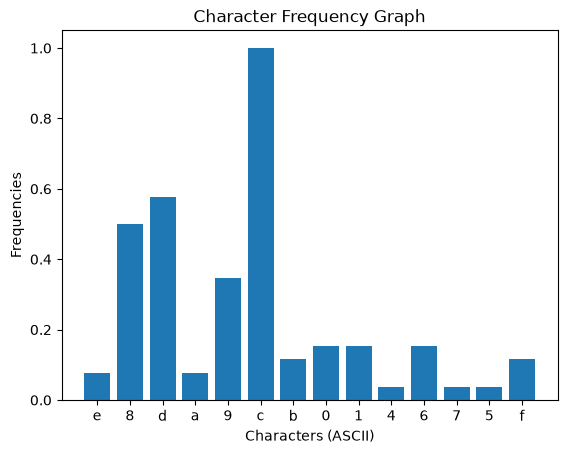

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
def frequency_counter(text: str)->dict:
    """
    Finds the frequency of each character in the ciphertext_hex

    Args:
        text: Takes the text from the ciphertext_hex in data.csv. Turns text into string type.

    Returns:
        frequency: The dictionary of how much a specific character is in the ciphertext_hex.
    """
    
    frequency = {}
    for char in text:
        if char in frequency:
            frequency[char] += 1
        else:
            frequency[char] = 1
    return frequency
df = pd.read_csv("data.csv")
for i in range(10):
    ciphertext_hex = bytes.fromhex(df.at[i, "ciphertext_hex"])
    char_counts = frequency_counter(ciphertext_hex)
    characters = list(char_counts.keys())
    frequencies = list(char_counts.values())
    freq_normalized = [i/float(max(frequencies)) for i in frequencies]
    plt.close() #Close plotted graphs so they dont stack
    #Plot axis and labels
    plt.bar(characters, freq_normalized)
    plt.xlabel("Characters (ASCII)") #ASCII charts because some utf-8 chars cannot be rendered properly
    plt.ylabel("Frequencies")
    plt.title("Character Frequency Graph")
    plt.savefig(f"./freqgraphs/freqgraph_index_{i}")

### xor functions
Not sure if these will be useful or not.

In [ ]:

def xor(word: str, key: int):
    chars = []
    for i in word:
        chars.append(chr(ord(i)^key))
    return("".join(chars))

def rotating_xor(word: str, key: int):
    chars = []
    for i in word:
        key+=1
        chars.append(chr(ord(i)^key))
    return("".join(chars))


print(xor("m`iij", 5))
print(rotating_xor("nbdee", 5))


### Training Section
This section contains all the actual stuff where we will train the model

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense #might need different layers later, but right now just using Dense.
